In [2]:
%config InlineBackend.figure_formats = ['retina']
import robodraw

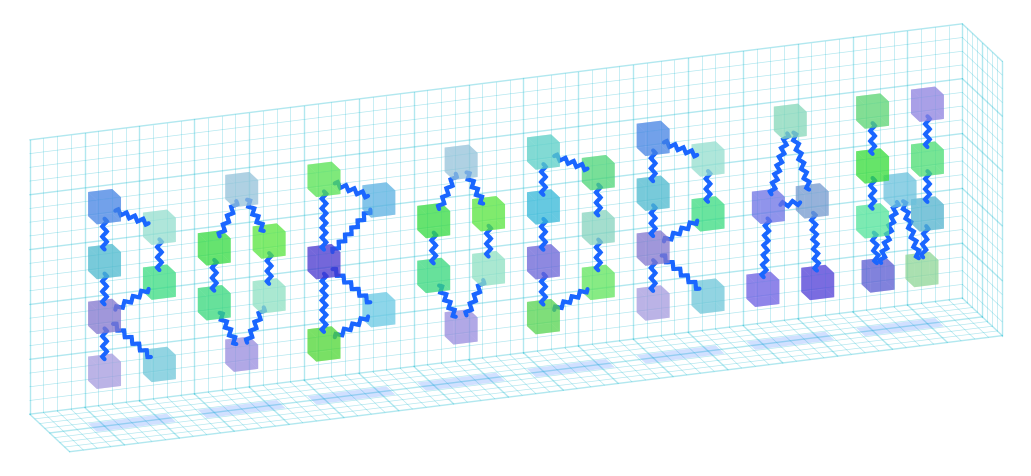

In [3]:
r = 0.22

d = robodraw.Drawing(
    projection=(20, 20)
    # projection="isometric",
)

edges_lookup = {
    "A": [
        ((0, 0), (0.1, 1.5)),
        ((0.1, 1.5), (0.5, 3)),
        ((0.5, 3), (0.9, 1.5)),
        ((0.9, 1.5), (1, 0)),
        ((0.1, 1.5), (0.9, 1.5)),
    ],
    "B": [
        ((0, 0), (0, 1.5)),
        ((0, 1.5), (0, 3)),
        ((0, 3), (1, 2.5)),
        ((1, 2.5), (0, 1.5)),
        ((0, 1.5), (1, 0.5)),
        ((1, 0.5), (0, 0)),
    ],
    "D": [
        ((0, 0), (0, 1)),
        ((0, 1), (0, 2)),
        ((0, 2), (0, 3)),
        ((0, 3), (1, 2.5)),
        ((1, 2.5), (1, 1.5)),
        ((1, 1.5), (1, 0.5)),
        ((1, 0.5), (0, 0)),
    ],
    "O": [
        ((0.5, 0), (0, 1)),
        ((0, 1), (0, 2)),
        ((0, 2), (0.5, 3)),
        ((0.5, 3), (1, 2)),
        ((1, 2), (1, 1)),
        ((1, 1), (0.5, 0)),
    ],
    "R": [
        ((0, 0), (0, 1)),
        ((0, 1), (0, 2)),
        ((0, 2), (0, 3)),
        ((0, 3), (1, 2.5)),
        ((1, 2.5), (1, 1.5)),
        ((1, 1.5), (0, 1)),
        ((0, 1), (1, 0)),
    ],
    "W": [
        ((0, 3), (0, 2)),
        ((0, 2), (0, 1)),
        ((0, 1), (0.1, 0)),
        ((0.1, 0), (0.5, 1.5)),
        ((0.5, 1.5), (0.9, 0)),
        ((0.9, 0), (1, 1)),
        ((1, 1), (1, 2)),
        ((1, 2), (1, 3)),
    ],
}

for i, letter in enumerate("ROBODRAW"):
    with d.translate(i * 2):
        edges = edges_lookup[letter]
        nodes = {v for edge in edges for v in edge}

        for cooa, coob in edges:
            d.zigzag(
                (cooa[0], 0, cooa[1]),
                (coob[0], 0, coob[1]),
                shorten=r,
                width=0.04,
                lw=1.5,
                color=(0.1, 0.4, 1.0),
            )
        for coo in nodes:
            color = robodraw.hash_to_color(
                str((coo, letter)), hmin=0.3, hmax=0.7
            )
            d.cube(
                (coo[0], 0, coo[1]),
                radius=r,
                hatch="",
                color=color,
                alpha=0.5,
                linewidth=0,
            )

d.grid3d(ticklabels=False)

# draw shadow after grid
for i, letter in enumerate("ROBODRAW"):
    with d.translate(i * 2):
        edges = edges_lookup[letter]
        nodes = {v for edge in edges for v in edge}
        d.shape(
            [
                (0 - r, -r, -1),
                (0 - r, +r, -1),
                (1 + r, +r, -1),
                (1 + r, -r, -1),
            ],
            linewidth=0,
            color=(0.1, 0.4, 1, 0.2),
        )

d.savefig("robodraw-header.png")

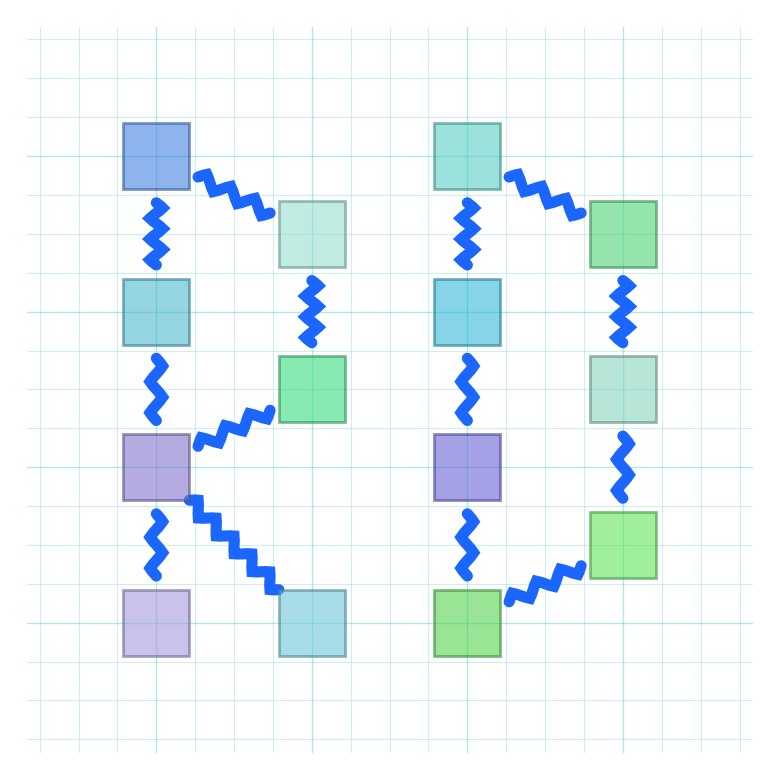

In [6]:
r = 0.3

d = robodraw.Drawing()
for i, letter in enumerate("RD"):
    with d.translate(i * 2):
        edges = edges_lookup[letter]
        nodes = {v for edge in edges for v in edge}

        for cooa, coob in edges:
            d.zigzag(
                (cooa[0], cooa[1]),
                (coob[0], coob[1]),
                shorten=r,
                width=0.04,
                lw=4,
                color=(0.1, 0.4, 1.0),
            )
        for coo in nodes:
            color = robodraw.hash_to_color(
                str((coo, letter)), hmin=0.3, hmax=0.7
            )
            d.square(
                (coo[0], coo[1]),
                radius=r,
                hatch="",
                color=color,
                alpha=0.6,
                # linewidth=0,
            )

d.grid(ticklabels=False)
d.savefig("robodraw-icon.png")

In [7]:
from PIL import Image

img = Image.open("robodraw-icon.png")
img.save(
    "robodraw.ico",
    format="ICO",
    sizes=[(16, 16), (32, 32), (48, 48), (64, 64), (128, 128), (256, 256)],
)